# 🧠 Building a Complete RAG Pipeline over 
### Local model with **Ollama** + **LangChain** + **LangGraph** + **LangSmith**

This notebook walks you through a **full Retrieval-Augmented Generation (RAG)** system, **step by step**, in plain language.

**Goal:** Ask questions about the *Attention Is All You Need* PDF and get answers that are grounded in the paper itself — not made up.

**The simple idea behind RAG (open-book exam):**
> Instead of the model answering from memory (closed-book), we first **find** the relevant pages of the paper, then **hand them to the model** and ask it to answer using only those pages. Fewer mistakes, real sources.

**What each tool does (one line each):**

| Tool | Think of it as... | Job in this notebook |
|------|-------------------|----------------------|
| **Ollama** | The engine running on *your* computer | Runs the chat model and the embedding model locally (free, private) |
| **LangChain** | A box of Lego bricks | Ready-made parts: load PDF, split text, talk to the model, talk to the database |
| **LangGraph** | The recipe / flowchart | Connects the bricks and controls the order, including *if-this-then-that* decisions |
| **LangSmith** | A flight recorder (black box) | Records every step so you can see and debug what happened |

We explain **why we need each one** right before we use it.

## Step 0 — Install the libraries

Run this once. The `-q` keeps the output short.

> 💡 **Why these packages?**
> - `langchain`, `langchain-community`, `langchain-core`, `langchain-text-splitters` → the core Lego bricks (loaders, splitters, prompts).
> - `langchain-ollama` → lets LangChain talk to your **local** Ollama models.
> - `langchain-chroma` + `chromadb` → the **vector database** that stores the paper as searchable numbers.
> - `langgraph` → builds the step-by-step **flow** of our pipeline.
> - `langsmith` → records traces for debugging.
> - `pypdf` → reads the PDF file.

In [1]:
%pip install -q -U \
    langchain langchain-community langchain-core langchain-text-splitters \
    langchain-ollama langchain-chroma chromadb \
    langgraph langsmith pypdf

Note: you may need to restart the kernel to use updated packages.


## Step 1 — Get Ollama and pull the two models

RAG needs **two different kinds of models**:

1. **A chat model** → reads the context and writes the answer (you said you have `gemma4:e2b`).
2. **An embedding model** → turns text into numbers so we can search by *meaning*. Chat models are not good at this, so we use a small dedicated one: `nomic-embed-text`.

Open a **terminal** (not the notebook) and run:

```bash
# make sure the Ollama app/server is running first
ollama pull gemma4:e2b          # your chat model
ollama pull nomic-embed-text    # the embedding model (small & fast)

ollama list                     # check the EXACT names you have
```

> ⚠️ **Important:** Ollama is picky about names. Whatever `ollama list` prints is what you must use below.
> If `gemma4:e2b` isn't found, copy the exact tag from `ollama list` (for example it might be `gemma3:4b`, `gemma2:2b`, etc.) and paste it into `LLM_MODEL` in Step 3.

## Step 2 — Turn on LangSmith (the "black box recorder")

**Why LangSmith?** In a RAG pipeline a lot happens behind the scenes: *Which chunks were retrieved? What did the final prompt look like? How long did the model take? Why was the answer wrong?* LangSmith records all of this in a web dashboard so you can **see and debug** instead of guessing.

- Get a **free** API key at **smith.langchain.com** → Settings → API Keys.
- If you don't want it right now, just **skip/comment** this cell — the pipeline still runs fine without it.

In [ ]:
import os

# --- LangSmith tracing: set this BEFORE running any model/pipeline cells ---
# ⚠️ If you restart the kernel, you MUST run this cell again (env vars are wiped on restart).

os.environ["LANGSMITH_TRACING"]   = "true"
os.environ["LANGCHAIN_TRACING_V2"] = "true"          # same switch, older variable name (some libs still read this)
os.environ["LANGSMITH_API_KEY"]   = "your_api_key"   # <-- get a fresh key at smith.langchain.com -> Settings -> API Keys
os.environ["LANGCHAIN_API_KEY"]   = os.environ["LANGSMITH_API_KEY"]
os.environ["LANGSMITH_PROJECT"]   = "attention-rag"  # ONE project name, used everywhere
os.environ["LANGCHAIN_PROJECT"]   = os.environ["LANGSMITH_PROJECT"]

print("LangSmith tracing:", os.environ["LANGSMITH_TRACING"], "| project:", os.environ["LANGSMITH_PROJECT"])

LangSmith tracing: true | project: attention-rag


## Step 3 — Connect to your local models

Here we create two objects from **LangChain** that point at **Ollama**:

- `llm` → the chat model that writes answers. `temperature=0` makes it factual and repeatable (less "creative").
- `embeddings` → the model that converts text → vectors (lists of numbers).

> 💡 **Why LangChain here?** Without it you'd write raw HTTP calls to Ollama. LangChain gives you a clean `.invoke()` method and makes these models plug straight into the rest of the pipeline.

In [3]:
from langchain_ollama import ChatOllama, OllamaEmbeddings

LLM_MODEL   = "llama3.2:1b"        # <-- must match `ollama list` exactly
EMBED_MODEL = "nomic-embed-text:latest"  # <-- the embedding model you pulled

llm = ChatOllama(model=LLM_MODEL, temperature=0)
embeddings = OllamaEmbeddings(model=EMBED_MODEL)

# Quick smoke test that the chat model responds:
print(llm.invoke("Reply with exactly one word: ready").content)

Yes.


## Step 4 — Load the PDF

**What this does:** reads the paper and turns it into a list of LangChain `Document` objects — **one per page**. Each `Document` has `.page_content` (the text) and `.metadata` (like the page number, which we'll use to show sources).

> 💡 **Why a LangChain loader?** PDFs are messy. `PyPDFLoader` handles the extraction and gives us a clean, uniform format that the next steps understand.

> 📂 **Put `Attention_all_you_need.pdf` in the same folder as this notebook**, or change `PDF_PATH` to its full path.

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

PDF_PATH = r"your_pdf_path.pdf"   # change to full path if needed

loader = PyPDFLoader(PDF_PATH)
pages = loader.load()

print(f"Loaded {len(pages)} pages.")
print("\n--- First 400 characters of page 1 ---\n")
print(pages[0].page_content[:400])

Loaded 15 pages.

--- First 400 characters of page 1 ---

Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
G


## Step 5 — Split the pages into small chunks

**Why split?** A full page is too big to search precisely and too big to stuff into the model. We cut the text into **small overlapping pieces** (chunks). Each chunk is one searchable "fact card".

- `chunk_size=1000` → about 1000 characters per chunk (a few paragraphs).
- `chunk_overlap=150` → neighboring chunks share 150 characters so a sentence cut in half isn't lost.

**Example:** the page describing "Scaled Dot-Product Attention" becomes a few chunks. Later, when you ask about it, we fetch only those chunks — not the whole paper.

> 💡 `RecursiveCharacterTextSplitter` tries to split on natural boundaries first (paragraphs → lines → sentences → words), so chunks stay readable.

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks = splitter.split_documents(pages)

print(f"{len(pages)} pages  ->  {len(chunks)} chunks")
print("\n--- Example chunk ---\n")
print(chunks[10].page_content[:300])
print("\n(from page:", chunks[10].metadata.get("page"), ")")

15 pages  ->  49 chunks

--- Example chunk ---

layers, produce outputs of dimensiondmodel = 512.
Decoder: The decoder is also composed of a stack ofN = 6 identical layers. In addition to the two
sub-layers in each encoder layer, the decoder inserts a third sub-layer, which performs multi-head
attention over the output of the encoder stack. Simil

(from page: 2 )


## Step 6 — Embed the chunks and store them in a vector database

This is the heart of "retrieval".

1. **Embed:** the embedding model turns each chunk into a **vector** (a long list of numbers) that captures its *meaning*. Chunks about similar topics get similar numbers.
2. **Store:** we save all those vectors in **Chroma**, a database built for fast "find the most similar" searches.

**Example:** "scaled dot-product attention" and "we divide by the square root of d_k" end up with *nearby* vectors, so a question about one will also surface the other.

> 💡 **Why a vector database (not Ctrl+F)?** Keyword search misses meaning. Ask *"how does the model handle word order?"* and keyword search finds nothing, but vector search returns the **positional encoding** chunk — because it understands the *idea*, not just exact words.

> `persist_directory` saves the database to disk, so next time you can load it instead of re-embedding (which costs time).

⏳ The first run embeds every chunk, so it can take a minute or two on a local machine.

> ⚠️ **Run-order gotcha (this caused your `NameError`):** this cell uses `embeddings` from **Step 3** and `chunks` from **Step 5**. If you restart the kernel, re-run Steps 2 → 3 → 4 → 5 first (or just use *Run All*). A restarted kernel forgets every variable.

In [8]:
from langchain_chroma import Chroma

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="attention_paper",
    persist_directory="./chroma_db",   # saved to disk for reuse
)

# A "retriever" is just the vector store wrapped so it returns the top-k matches.
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})  # fetch 4 best chunks

print("Vector store ready with", vectorstore._collection.count(), "chunks.")

Vector store ready with 49 chunks.


In [9]:
import os
os.getcwd()

'C:\\Users\\DELL\\Desktop'

In [10]:
import os
os.getcwd()

'C:\\Users\\DELL\\Desktop'

## Step 7 — Test retrieval on its own

Before building the full pipeline, let's confirm the search works. We ask a question and print the chunks it pulls back. **No model yet — this is pure search.**

In [11]:
test_docs = retriever.invoke("What is scaled dot-product attention?")

for i, d in enumerate(test_docs, 1):
    print(f"[{i}] page {d.metadata.get('page')}:")
    print("    ", d.page_content[:160].replace("\n", " "), "...\n")

[1] page 3:
     Scaled Dot-Product Attention  Multi-Head Attention Figure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several attention lay ...

[2] page 3:
     the matrix of outputs as: Attention(Q,K,V ) = softmax(QK T √dk )V (1) The two most commonly used attention functions are additive attention [2], and dot-product ...

[3] page 3:
     extremely small gradients 4. To counteract this effect, we scale the dot products by 1√dk . 3.2.2 Multi-Head Attention Instead of performing a single attention  ...

[4] page 4:
     information flow in the decoder to preserve the auto-regressive property. We implement this inside of scaled dot-product attention by masking out (setting to−∞) ...



## Step 8 — Write the prompt (the instructions for the model)

The prompt is where we **force the model to stay grounded**. We tell it: *answer using ONLY the context; if it's not there, say so.* This is what stops the model from inventing facts.

`{context}` will be filled with the retrieved chunks, and `{question}` with the user's question.

In [12]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
    """You are a precise research assistant. Answer the QUESTION using ONLY the CONTEXT below.
- If the answer is not in the context, reply exactly: "I could not find this in the document."
- Keep the answer short and clear. Use simple words.

CONTEXT:
{context}

QUESTION: {question}

ANSWER:"""
)

print(prompt.format(context="<chunks go here>", question="<user question>"))

Human: You are a precise research assistant. Answer the QUESTION using ONLY the CONTEXT below.
- If the answer is not in the context, reply exactly: "I could not find this in the document."
- Keep the answer short and clear. Use simple words.

CONTEXT:
<chunks go here>

QUESTION: <user question>

ANSWER:


## Step 9 — Build the pipeline as a graph with **LangGraph**

### Why LangGraph? (read this — it's the key idea)
So far we have separate bricks: a retriever, a prompt, a model. We need to **connect them in order**: *question → retrieve chunks → build prompt → generate answer.*

You *could* glue them with a simple chain (a straight line). **LangGraph** is better because it treats the pipeline as a **flowchart of nodes** that share a common "clipboard" (the **State**). This gives you superpowers a straight line can't:
- **Branching** — *"if the chunks aren't relevant, don't answer / search again"* (we add this in Step 12).
- **Loops & retries**, **memory**, and **easy visualization** of the flow.
- Every node is automatically traced in LangSmith.

> 🧩 **Analogy:** a plain chain is a printed list of directions. LangGraph is a GPS that can **re-route** when something changes.

### The three pieces of any LangGraph
1. **State** — a shared dictionary passed between steps. Ours holds `question`, `context`, `answer`.
2. **Nodes** — plain Python functions. Each reads the State and returns the part it changed.
3. **Edges** — the wiring: `START → retrieve → generate → END`.

In [13]:
from typing import List
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END


# 1) STATE: the shared clipboard that flows through the graph
class RAGState(TypedDict):
    question: str            # what the user asked
    context: List[Document]  # chunks we retrieved
    answer: str              # the final answer


# 2) NODE A — retrieve: find the most relevant chunks
def retrieve(state: RAGState):
    docs = retriever.invoke(state["question"])
    return {"context": docs}          # only return what changed


# 3) NODE B — generate: build the prompt and ask the model
def generate(state: RAGState):
    context_text = "\n\n".join(d.page_content for d in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": context_text})
    response = llm.invoke(messages)
    return {"answer": response.content}


# 4) EDGES: wire the nodes together
builder = StateGraph(RAGState)
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)
builder.add_edge(START, "retrieve")     # start here
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)       # finish here

graph = builder.compile()
print("Graph compiled ✅")

Graph compiled ✅


### See the flow as a picture
LangGraph can draw your pipeline. (The PNG uses an online renderer; if you're offline we fall back to a text diagram.)

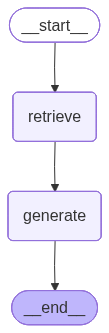

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("(PNG renderer unavailable, showing text diagram instead)\n")
    print(graph.get_graph().draw_ascii())

## Step 10 — Ask questions about the paper 🎉

Now we run the whole graph. Give it a `question`; it returns the filled-in State with the `answer` and the `context` we can use to show **sources**.

In [14]:
result = graph.invoke({"question": "What are the two sub-layers in each encoder layer?"})
print(result["answer"])

The two sub-layers in each encoder layer are a multi-head self-attention mechanism and a simple, position-wise fully connected feed-forward network.


In [15]:
def ask(question: str):
    out = graph.invoke({"question": question})
    pages_used = sorted({d.metadata.get("page") for d in out["context"]})
    print("❓", question)
    print("✅", out["answer"])
    print("📄 sources (pages):", pages_used)
    print("-" * 70)

# Try a few questions grounded in the paper:
ask("How many attention heads does the base Transformer use, and what is d_k?")
ask("Why do the authors divide the dot products by the square root of d_k?")
ask("What positional encoding does the paper use and why sine/cosine?")
ask("What BLEU score did the big Transformer get on English-to-German?")
ask("Who won the football World Cup in 1998?")   # not in the paper -> should refuse

❓ How many attention heads does the base Transformer use, and what is d_k?
✅ The Transformer uses 8 attention heads. 
d_k = dv = dmodel / h = 64.
📄 sources (pages): [0, 1, 2, 4]
----------------------------------------------------------------------
❓ Why do the authors divide the dot products by the square root of d_k?
✅ They divide the dot products by √dk to counteract the effect of large gradients in the softmax function when dk is small.
📄 sources (pages): [3, 4]
----------------------------------------------------------------------
❓ What positional encoding does the paper use and why sine/cosine?
✅ The paper uses sine and cosine functions of different frequencies as positional encodings. It chooses these because it hypothesized that they would allow the model to easily learn to attend by relative positions, since for any fixed offset, PE pos+k can be represented as a linear function of PE pos.
📄 sources (pages): [5, 7, 8, 9]
--------------------------------------------------------

## Step 11 — Look at the trace in LangSmith

If you set your key in Step 2, open **smith.langchain.com**, pick the **`attention-rag`** project, and click the latest run. You'll see a **tree** of everything that happened:

- the `retrieve` node and the exact chunks it returned,
- the full prompt sent to the model,
- the model's answer and how long each step took.

> 💡 **This is the payoff of LangSmith:** when an answer looks wrong, you can instantly tell *whether retrieval pulled the wrong chunks* or *the model misread good chunks* — without adding `print()` everywhere.

## Step 12 (Bonus) — Why LangGraph really shines: add a decision step 🌟

A straight line always answers, even when retrieval found nothing useful. Let's make the graph **smarter** by adding a **conditional edge**: after retrieving, a `grade` step asks the model *"do these chunks actually contain the answer?"*

- **YES →** go to `generate` (answer normally).
- **NO →** go to `reject` (politely say it's not in the document) — saving a wasted model call.

This *if-this-then-that* branching is exactly what you **cannot** do cleanly with a simple chain, and it's the core reason LangGraph exists.

In [16]:
# --- a node that decides quality, and a node that politely declines ---

def grade(state: RAGState) -> str:
    # Return the name of the next node, based on whether the context is relevant.
    ctx = "\n\n".join(d.page_content for d in state["context"])
    verdict = llm.invoke(
        "Do the NOTES contain enough information to answer the QUESTION? "
        "Reply with only one word: YES or NO.\n\n"
        f"NOTES:\n{ctx}\n\nQUESTION: {state['question']}"
    ).content.strip().upper()
    return "generate" if "YES" in verdict else "reject"


def reject(state: RAGState):
    return {"answer": "I could not find this in the document."}


# --- build a second graph that uses a conditional edge ---
builder2 = StateGraph(RAGState)
builder2.add_node("retrieve", retrieve)
builder2.add_node("generate", generate)
builder2.add_node("reject", reject)

builder2.add_edge(START, "retrieve")
# conditional edge: run `grade`, then jump to whichever node it names
builder2.add_conditional_edges("retrieve", grade, {"generate": "generate", "reject": "reject"})
builder2.add_edge("generate", END)
builder2.add_edge("reject", END)

graph2 = builder2.compile()

# Test both a real and a fake question:
print(graph2.invoke({"question": "What optimizer and learning rate schedule were used?"})["answer"])
print("---")
print(graph2.invoke({"question": "What is the recipe for chocolate cake?"})["answer"])

The optimizer was Adam with β1 = 0.9 and β2 = 0.98, and the learning rate schedule was lrate = d - 0.5 * min(step_num - 0.5, step_num * warmup_steps - 1.5).
---
I could not find this in the document.


## ✅ Recap — what you built and why each tool mattered

**The pipeline:** `PDF → split into chunks → embed → store in Chroma → retrieve top chunks → prompt → local model answers (with sources).`

| Tool | Why it was needed |
|------|-------------------|
| **Ollama** | Ran your `gemma4:e2b` chat model and the embedding model **locally** — free and private, no data leaves your machine. |
| **LangChain** | Gave the ready-made bricks (`PyPDFLoader`, `RecursiveCharacterTextSplitter`, `Chroma`, `ChatOllama`, prompts) so you didn't hand-code the plumbing. |
| **LangGraph** | Connected the bricks into a controllable **flow**, and let you add a **decision step** (answer vs. refuse) that a plain chain can't do. |
| **LangSmith** | Recorded every step so you can **debug** *why* an answer was good or bad. |

### Ideas to go further
- **Reuse the saved database:** skip Steps 4–6 next time with
  `Chroma(collection_name="attention_paper", embedding_function=embeddings, persist_directory="./chroma_db")`.
- **Show better sources:** print the exact sentences used, not just page numbers.
- **Hybrid search:** combine vector search with keyword search to catch exact terms like *"BLEU"* or *"d_model"*.
- **Add memory:** give the graph a `messages` field so it remembers earlier questions in a conversation.

Happy building! 🚀

In [17]:
# --- Verify the API key actually points at the workspace you are looking at ---
from langsmith import Client, traceable

client = Client()

# 1) List the projects this key can see. If "attention-rag" / your traces aren't in this
#    list, your key belongs to a DIFFERENT workspace than the one open in your browser.
print("Projects visible to this API key:")
for p in client.list_projects(limit=10):
    print("  -", p.name)

# 2) Send one tiny test trace
@traceable
def test_trace(x: str):
    return f"got: {x}"

print(test_trace("hello langsmith"))
print("Now refresh smith.langchain.com -> check the workspace switcher (top-left) -> open project:", 
      __import__("os").environ["LANGSMITH_PROJECT"])

Projects visible to this API key:
  - attention-rag
got: hello langsmith
Now refresh smith.langchain.com -> check the workspace switcher (top-left) -> open project: attention-rag
